#**[프로젝트] 서울 전월세 가격 변동 요인 분석 - 금리와 지하철 접근성을 중심으로**
- [서울시 부동산 전월세가 정보](https://data.seoul.go.kr/dataList/OA-21276/S/1/datasetView.do) : 서울 부동산 정보광장에서 제공하는 전월세가 정보입니다. 자치구, 법정동, 건물명, 임대건물명, 전월세구분, 보증금, 임대료, 계약년도 등의 전월세 정보를 제공합니다.

# 1.데이터분석의 주제 선정
 - 서울시 전월세 실거래 데이터와 금리 및 지하철 접근성 데이터를 결합하여 금리 변화와 주거 입지에 따른 전월세 가격 변동을 분석한다.
 - 이를 통해 전월세 가격의 주요 변동 요인과 시기별, 지역별 가격 차이를 파악하고 청년층의 주거지역 및 거주 계획 수립을 지원하는 데이터 기반 정보를 제공한다.


# 2.데이터 수집
## 원본 데이터 출처
- [서울시 부동산 전월세가 정보](https://data.seoul.go.kr/dataList/OA-21276/S/1/datasetView.do)
- [한국은행 기준금리 및 여수신금리](ecos.bok.or.kr/#/Short/3936eb)
- [서울교통공사_1_8호선 역사 좌표(위경도) 정보](https://data.seoul.go.kr/dataList/OA-22534/F/1/datasetView.do)
- [서울교통공사_9호선 2_3단계 역사 좌표(위경도) 정보](https://data.seoul.go.kr/dataList/OA-22447/F/1/datasetView.do)

## 활용 데이터
- 데이터 공유폴더 : https://drive.google.com/drive/folders/1tdWmbPR2a2lcKZbFxpWXeqmJE8CmM3yl?usp=sharing

- Data1 : 서울시 전월세 실거래 데이터
  - https://drive.google.com/drive/folders/1T5ePaii9RHiQ2Bbr6cDbHB9LnOo8mYtM?usp=drive_link

- Data2 : 한국은행 기준금리
  - https://drive.google.com/drive/folders/19FUt34OanrYC_8IrD02ZjmaH3RVlPGI4?usp=drive_link

- Data3 : 지하철역 위경도
  - https://drive.google.com/drive/folders/1DafnCTXbMq9Zo1BL7r4p60rVOX8uVXY7?usp=drive_link

##2-1. colab에서 한글 사용하기

In [1]:
!pip install koreanize-matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 19.5 MB/s eta 0:00:00


In [2]:
import requests
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import koreanize_matplotlib
from google.colab import files

##2-2. 데이터 불러오기

In [4]:
df_list = []

# 2016-2021 txt 파일 불러오기
for year in range(2016, 2022):
    file_path = (f"/content/서울특별시_전월세가_{year}.txt")

    df_year = pd.read_csv(file_path, encoding="cp949", low_memory=False)
    df_list.append(df_year)

    print(f"{year}년: {len(df_year)}건")

# 2022~2025 CSV 파일 불러오기
for year in range(2022, 2026):
    file_path = (f"/content/서울특별시_전월세가_{year}.csv")

    # 2023년만 utf-8, 나머지는 cp949
    if year == 2023:
        encoding = "utf-8-sig"
    else:
        encoding = "cp949"

    df_year = pd.read_csv(file_path, encoding=encoding, low_memory=False)
    df_list.append(df_year)

    print(f"{year}년: {len(df_year)}건")

2016년: 382412건
2017년: 398292건
2018년: 436595건
2019년: 458969건
2020년: 509038건
2021년: 524675건
2022년: 560665건
2023년: 545813건
2024년: 522001건
2025년: 1084942건


In [5]:
# 10개년 데이터 통합
df = pd.concat(df_list, ignore_index=True)

In [7]:
df.columns

Index(['접수년도', '자치구코드', '자치구명', '법정동코드', '법정동명', '지번구분코드', '지번구분', '본번', '부번',
       '층', '계약일', '전월세구분', '임대면적', '보증금(만원)', '임대료(만원)', '건물명', '건축년도',
       '건물용도', '계약기간', '신규계약구분', '갱신청구권사용', '종전보증금', '종전임대료'],
      dtype='object')

## 2-3 데이터 확인하기
- 건수, 결측치, 중복, 이상치를 확인하고 정리하세요

### 2-3-1. 건수

In [8]:
df.shape

(5423402, 23)

### 2-3-2. 중복
2025년 데이터가 타 연도 대비 약 2배 많아 중복 데이터 여부 확인

In [9]:
print(f"전체 행 수: {len(df):,}")

전체 행 수: 5,423,402


In [10]:
print("중복 행 수:", f"{df.duplicated().sum():,}")

중복 행 수: 452,458


In [11]:
# 연도별 중복 발생 확인
for i, df_year in enumerate(df_list, start=2016):
    print(
        i,
        f"전체: {len(df_year):,}",
        f"중복: {df_year.duplicated().sum():,}"
    )

2016 전체: 382,412 중복: 0
2017 전체: 398,292 중복: 0
2018 전체: 436,595 중복: 0
2019 전체: 458,969 중복: 0
2020 전체: 509,038 중복: 0
2021 전체: 524,675 중복: 0
2022 전체: 560,665 중복: 0
2023 전체: 545,813 중복: 0
2024 전체: 522,001 중복: 1
2025 전체: 1,084,942 중복: 446,244


In [12]:
df_2025 = df_list[-1]

# 실제 중복 데이터 확인
display(df_2025[df_2025.duplicated(keep=False)].head(20))

,접수년도,자치구코드,자치구명,법정동코드,법정동명,지번구분코드,지번구분,본번,부번,층,...,보증금(만원),임대료(만원),건물명,건축년도,건물용도,계약기간,신규계약구분,갱신청구권사용,종전보증금,종전임대료
133690,2025,11260.0,중랑구,10500.0,망우동,NaN,NaN,NaN,NaN,NaN,...,500,40,NaN,2015.0,단독다가구,25.09~27.09,신규,NaN,NaN,NaN
133691,2025,11410.0,서대문구,11600.0,창천동,NaN,NaN,NaN,NaN,NaN,...,300,51,NaN,1984.0,단독다가구,25.10~26.04,신규,NaN,NaN,NaN
133692,2025,11590.0,동작구,10700.0,사당동,NaN,NaN,NaN,NaN,NaN,...,500,32,NaN,1996.0,단독다가구,25.10~27.10,신규,NaN,NaN,NaN
133693,2025,11710.0,송파구,10600.0,삼전동,1.0,대지,106.0,10.0,2.0,...,500,55,(106-10),2011.0,연립다세대,25.10~27.10,신규,NaN,NaN,NaN
133694,2025,11710.0,송파구,10600.0,삼전동,1.0,대지,112.0,8.0,2.0,...,12000,0,(112-8),2001.0,연립다세대,25.10~27.10,갱신,NaN,12000.0,NaN
133695,2025,11710.0,송파구,10600.0,삼전동,1.0,대지,116.0,9.0,3.0,...,3000,74,(116-9),2007.0,연립다세대,25.12~27.11,신규,NaN,NaN,NaN
133696,2025,11710.0,송파구,10400.0,송파동,1.0,대지,117.0,30.0,3.0,...,15000,14,(117-30),2022.0,연립다세대,25.10~27.10,신규,NaN,NaN,NaN
133697,2025,11710.0,송파구,10600.0,삼전동,1.0,대지,106.0,10.0,2.0,...,500,55,(106-10),2011.0,연립다세대,25.10~27.10,신규,NaN,NaN,NaN
133698,2025,11230.0,동대문구,10300.0,제기동,1.0,대지,1185.0,0.0,1.0,...,12000,50,(1185-0),1980.0,연립다세대,25.10~27.10,신규,NaN,NaN,NaN
133699,2025,11560.0,영등포구,11700.0,당산동,1.0,대지,121.0,126.0,1.0,...,1000,40,(121-126),1997.0,오피스텔,25.10~27.10,신규,NaN,NaN,NaN


In [13]:
# 중복 제거
df = df.drop_duplicates()

In [14]:
print(f"중복 제거 후 전체 행 수: {len(df):,}")

중복 제거 후 전체 행 수: 4,970,944


### 2-3-3. 결측치

In [15]:
# 결측치
df.isnull().sum()

,0
접수년도,0
자치구코드,3
자치구명,3
법정동코드,13
법정동명,15
지번구분코드,1411809
지번구분,1411809
본번,1410891
부번,1410891
층,1412423


## 2-4 데이터 전처리하기
- 결측값이 있는 행은 제거하고 시작하세요
- 필요한 경우 파생변수를 만드세요

In [16]:
df.columns

Index(['접수년도', '자치구코드', '자치구명', '법정동코드', '법정동명', '지번구분코드', '지번구분', '본번', '부번',
       '층', '계약일', '전월세구분', '임대면적', '보증금(만원)', '임대료(만원)', '건물명', '건축년도',
       '건물용도', '계약기간', '신규계약구분', '갱신청구권사용', '종전보증금', '종전임대료'],
      dtype='object')

### 2-4-1. address 컬럼 생성

In [17]:
# 본번 / 부번 / 법정동명 / 자치구명 데이터 타입 확인

print(df["자치구명"].dtype)
print(df["법정동명"].dtype)
print(df["본번"].dtype)
print(df["부번"].dtype)

object
object
float64
float64


In [18]:
def make_address(row):
    sido = "서울특별시"
    gu = row["자치구명"]
    dong = row["법정동명"]
    bonbun = row["본번"]
    bubun = row["부번"]

    # 필수 주소 정보가 없는 경우
    if (
        pd.isna(gu)
        or pd.isna(dong)
        or pd.isna(bonbun)
    ):
        return pd.NA

    # 문자열 공백 제거 후 빈 값 확인
    gu = str(gu).strip()
    dong = str(dong).strip()

    if gu == "" or dong == "":
        return pd.NA

    # 본번이 숫자가 아닌 경우
    try:
        bonbun = int(float(bonbun))
    except (ValueError, TypeError):
        return pd.NA

    # 부번이 없거나 0인 경우
    if pd.isna(bubun) or bubun == 0:
        return f"{sido} {gu} {dong} {bonbun}"

    # 부번이 존재하는 경우
    try:
        bubun = int(float(bubun))
    except (ValueError, TypeError):
        return f"{sido} {gu} {dong} {bonbun}"

    return f"{sido} {gu} {dong} {bonbun}-{bubun}"

In [19]:
# 완전한 주소 생성
df["address"] = df.apply(make_address, axis=1)

In [22]:
# 결과 확인
print(f"주소 생성 완료: {df['address'].notna().sum():,}건")
print(f"주소 결측: {df['address'].isna().sum():,}건")

print(df[["자치구명", "법정동명", "본번", "부번", "address"]].head(10))

주소 생성 완료: 3,560,051건
주소 결측: 1,410,893건
  자치구명   법정동명   본번   부번             address
0  용산구  원효로2가  1.0  0.0   서울특별시 용산구 원효로2가 1
1  마포구   노고산동  1.0  1.0  서울특별시 마포구 노고산동 1-1
2  마포구   노고산동  1.0  1.0  서울특별시 마포구 노고산동 1-1
3  마포구   노고산동  1.0  1.0  서울특별시 마포구 노고산동 1-1
4  마포구   노고산동  1.0  1.0  서울특별시 마포구 노고산동 1-1
5  마포구   노고산동  1.0  1.0  서울특별시 마포구 노고산동 1-1
6  마포구   노고산동  1.0  1.0  서울특별시 마포구 노고산동 1-1
7  마포구   노고산동  1.0  1.0  서울특별시 마포구 노고산동 1-1
8  마포구   노고산동  1.0  1.0  서울특별시 마포구 노고산동 1-1
9  마포구   노고산동  1.0  1.0  서울특별시 마포구 노고산동 1-1


In [23]:
df.loc[
    df["address"].isna(),
    ["자치구명", "법정동명", "본번", "부번", "address"]
]

,자치구명,법정동명,본번,부번,address
152007,관악구,NaN,28.0,1.0,<NA>
256619,서초구,신원동,NaN,NaN,<NA>
256620,서초구,신원동,NaN,NaN,<NA>
256621,서초구,신원동,NaN,NaN,<NA>
256622,서초구,신원동,NaN,NaN,<NA>
...,...,...,...,...,...
5423397,관악구,신림동,NaN,NaN,<NA>
5423398,관악구,봉천동,NaN,NaN,<NA>
5423399,동대문구,휘경동,NaN,NaN,<NA>
5423400,광진구,구의동,NaN,NaN,<NA>


In [24]:
# 주소 결측 데이터 제거
df = df.dropna(subset=["address"]).copy()

print(f"주소 결측 제거 후: {len(df):,}건")

주소 결측 제거 후: 3,560,051건


In [25]:
print(f"전체 데이터: {len(df):,}건")
print(f"고유 주소: {df['address'].nunique():,}건")

전체 데이터: 3,560,051건
고유 주소: 104,282건


In [26]:
output_path = "/content/Rental_Lease_Address_Cleaned.csv"
df.to_csv(output_path,index=False,encoding="utf-8-sig")


files.download("/content/Rental_Lease_Address_Cleaned.csv")
print(f"저장 완료: {output_path}")
print(f"데이터 크기: {df.shape}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

저장 완료: /content/Rental_Lease_Address_Cleaned.csv
데이터 크기: (3560051, 24)


### 2-4-2. 지오코딩
**전체 흐름**

- **1단계: 카카오 로컬 API**: 중복을 제거한 고유 주소만 추출해 좌표 변환<br>
- **2단계: VWorld 주소 API**: 1단계에서 실패한 주소만 재시도<br>
- **3단계: Google Geocoding API**: 2단계에서도 실패한 주소를 마지막으로 재시도

3단계를 모두 거친 최종 좌표를 원본 데이터의 `위도`, `경도` 컬럼에 병합

#### 환경 설정

In [27]:
!pip install tqdm -q

In [ ]:
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import requests
from tqdm import tqdm

# API 키 (본인이 발급받은 키로 교체해서 사용)
KAKAO_REST_API_KEY = "API_KEY"
VWORLD_API_KEY = "API_KEY"
GOOGLE_API_KEY = "API_KEY"

# 병렬 요청
MAX_WORKERS = 5
REQUEST_TIMEOUT = 10

In [ ]:
df = pd.read_csv(
    "/content/Rental_Lease_Address_Cleaned.csv",
    encoding="utf-8-sig"
)

#### 1단계 — 카카오 로컬 API 지오코딩

카카오 로컬 API의 **주소 검색**을 우선 사용하고, 결과가 없으면 **키워드 검색**으로 한 번 더 시도합니다(도로명·건물명이 섞여 인식되지 않는 주소를 보완하기 위함).

In [ ]:
KAKAO_ADDRESS_URL = "https://dapi.kakao.com/v2/local/search/address.json"
KAKAO_KEYWORD_URL = "https://dapi.kakao.com/v2/local/search/keyword.json"
KAKAO_HEADERS = {"Authorization": f"KakaoAK {KAKAO_REST_API_KEY}"}

def geocode_kakao(address):
    """카카오 주소 검색 → 실패 시 키워드 검색으로 재시도. (위도, 경도) 또는 (nan, nan) 반환."""
    try:
        for url in (KAKAO_ADDRESS_URL, KAKAO_KEYWORD_URL):
            response = requests.get(
                url, headers=KAKAO_HEADERS, params={"query": address}, timeout=REQUEST_TIMEOUT
            )
            if response.status_code == 200:
                documents = response.json().get("documents", [])
                if documents:
                    result = documents[0]
                    # 카카오 API: y = 위도, x = 경도
                    return float(result["y"]), float(result["x"])
            elif response.status_code == 429:
                print("ERROR: 카카오 API 요청 제한(429) - 잠시 대기 후 계속")
                time.sleep(1)
        return np.nan, np.nan
    except Exception as e:
        print(f"ERROR: 카카오 API 오류 ({address}) - {e}")
        return np.nan, np.nan

In [ ]:
# 고유 주소 리스트를 병렬로 지오코딩하고 {주소: (위도, 경도)} 딕셔너리를 반환
def run_geocoding(addresses, geocode_func, desc):
    results = {}
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = {executor.submit(geocode_func, addr): addr for addr in addresses}
        for future in tqdm(as_completed(futures), total=len(futures), desc=desc, unit="건"):
            addr = futures[future]
            results[addr] = future.result()
    return results

In [ ]:
# 고유 주소만 추출 - 중복 API 호출 방지
unique_addresses = df["address"].dropna().drop_duplicates().tolist()
print(f"전체 행: {len(df):,}건 | 고유 주소: {len(unique_addresses):,}건")

kakao_results = run_geocoding(unique_addresses, geocode_kakao, desc="1단계: 카카오 지오코딩")

kakao_df = pd.DataFrame(
    [{"address": addr, "위도": lat, "경도": lon} for addr, (lat, lon) in kakao_results.items()]
)

kakao_success = kakao_df["위도"].notna().sum()
print(f"카카오 성공: {kakao_success:,}건 / 실패: {len(kakao_df) - kakao_success:,}건")

1단계 결과를 원본 데이터에 병합

이후 단계에서는 **여기서 실패한 주소만** 대상으로 재시도합니다.

In [ ]:
df = df.merge(kakao_df, on="address", how="left")

print(f"전체 데이터: {len(df):,}건")
print(f"위경도 확보: {df['위도'].notna().sum():,}건")
print(f"위경도 미확보: {df['위도'].isna().sum():,}건")

#### 2단계 — VWorld 주소 API로 실패 주소 재시도

카카오에서 실패한 주소 중 **고유 주소만** 다시 추출해 VWorld(국토교통부 제공) 지번 주소 검색 API로 재시도합니다.

In [ ]:
VWORLD_URL = "https://api.vworld.kr/req/address"


def geocode_vworld(address):
    """VWorld 지번(PARCEL) 주소 검색. (위도, 경도) 또는 (nan, nan) 반환."""
    params = {
        "service": "address",
        "request": "getcoord",
        "version": "2.0",
        "crs": "EPSG:4326",   # WGS84 경위도로 반환
        "address": address,
        "refine": "true",
        "simple": "false",
        "format": "json",
        "type": "PARCEL",     # 지번 주소 검색
        "key": VWORLD_API_KEY,
    }

    try:
        response = requests.get(VWORLD_URL, params=params, timeout=REQUEST_TIMEOUT)
        response.raise_for_status()
        data = response.json()

        response_data = data.get("response", {})
        if response_data.get("status") != "OK":
            return np.nan, np.nan

        result = response_data.get("result")
        if isinstance(result, list):
            result = result[0] if result else None
        if not result:
            return np.nan, np.nan

        point = result.get("point")
        if not point:
            return np.nan, np.nan

        # VWorld point: x = 경도, y = 위도
        return float(point["y"]), float(point["x"])

    except Exception as e:
        print(f"⚠️ VWorld API 오류 ({address}): {e}")
        return np.nan, np.nan

In [ ]:
# 1단계에서 실패한 행만 대상으로, 고유 주소만 추출
failed_mask = df["위도"].isna() | df["경도"].isna()
retry_addresses_1 = df.loc[failed_mask, "address"].dropna().drop_duplicates().tolist()

print(f"2단계 재시도 대상 (고유 주소): {len(retry_addresses_1):,}건")

vworld_results = run_geocoding(retry_addresses_1, geocode_vworld, desc="2단계: VWorld 지오코딩")

vworld_df = pd.DataFrame(
    [{"address": addr, "위도_vworld": lat, "경도_vworld": lon} for addr, (lat, lon) in vworld_results.items()]
)

vworld_success = vworld_df["위도_vworld"].notna().sum()
print(f"VWorld 성공: {vworld_success:,}건 / 실패: {len(vworld_df) - vworld_success:,}건")

2단계 결과 병합

카카오 좌표가 없는 행에 한해서만 VWorld 결과로 채웁니다 (`fillna` 사용 — 기존에 이미 확보된 좌표는 덮어쓰지 않음).

In [ ]:
df = df.merge(vworld_df, on="address", how="left")

df["위도"] = df["위도"].fillna(df["위도_vworld"])
df["경도"] = df["경도"].fillna(df["경도_vworld"])

df = df.drop(columns=["위도_vworld", "경도_vworld"])

print(f"전체 데이터: {len(df):,}건")
print(f"위경도 확보: {df['위도'].notna().sum():,}건")
print(f"위경도 미확보: {df['위도'].isna().sum():,}건")

#### 3단계 — Google Geocoding API로 남은 실패 주소 재시도

카카오, VWorld 두 국내 API에서도 인식되지 않은 주소를 Google Geocoding API로 마지막으로 재시도합니다.

In [ ]:
from pathlib import Path

# 2단계까지 완료된 파일을 불러옵니다.

DATA_DIR = Path(r"C:\Users\SBA\Desktop\mypython\final-project\data")
MAIN_FILE = DATA_DIR / "Rental_and_Lease_Data_Geocoded.csv"
df = pd.read_csv(MAIN_FILE)

# Google Geocoding API
GOOGLE_URL = "https://maps.googleapis.com/maps/api/geocode/json"


def geocode_google(address):
    params = {
        "address": address,
        "key": GOOGLE_API_KEY,
        "language": "ko",
        "region": "kr",
    }

    try:
        response = requests.get(
            GOOGLE_URL,
            params=params,
            timeout=REQUEST_TIMEOUT
        )
        response.raise_for_status()
        data = response.json()

        if data.get("status") != "OK":
            return np.nan, np.nan

        results = data.get("results", [])
        if not results:
            return np.nan, np.nan

        location = results[0]["geometry"]["location"]

        return float(location["lat"]), float(location["lng"])

    except Exception as e:
        print(f"ERROR: Google API 오류 ({address}) - {e}")
        return np.nan, np.nan


C:\Users\SBA\AppData\Local\Temp\ipykernel_7604\1790069583.py:14: DtypeWarning: Columns (0: 계약기간, 1: 신규계약구분, 2: 갱신청구권사용) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(MAIN_FILE)


In [ ]:
# 위도 또는 경도 중 하나라도 없는 행
failed_mask = df["위도"].isna() | df["경도"].isna()

# 실패한 행에서 주소만 추출 → 결측 제거 → 중복 제거
retry_addresses_2 = (
    df.loc[failed_mask, "address"]
    .dropna()
    .drop_duplicates()
    .tolist()
)

print(f"3단계 재시도 대상 (고유 주소): {len(retry_addresses_2):,}건")


# Google Geocoding API 실행
google_results = run_geocoding(
    retry_addresses_2,
    geocode_google,
    desc="3단계: Google 지오코딩"
)

# Google 결과를 DataFrame으로 변환
google_df = pd.DataFrame(
    [
        {
            "address": addr,
            "위도_google": lat,
            "경도_google": lon
        }
        for addr, (lat, lon) in google_results.items()
    ],
    columns=["address", "위도_google", "경도_google"]
)

# 성공 / 실패 건수
google_success = google_df["위도_google"].notna().sum()

print(
    f"Google 성공: {google_success:,}건 / "
    f"실패: {len(google_df) - google_success:,}건"
)

3단계 재시도 대상 (고유 주소): 519건


3단계: Google 지오코딩: 100%|██████████| 519/519 [00:22<00:00, 23.30건/s]

Google 성공: 519건 / 실패: 0건


### 2-4-3. 결과 병합

In [ ]:
df = df.merge(google_df, on="address", how="left")

df["위도"] = df["위도"].fillna(df["위도_google"])
df["경도"] = df["경도"].fillna(df["경도_google"])

df = df.drop(columns=["위도_google", "경도_google"])

print(f"전체 데이터: {len(df):,}건")
print(f"위경도 확보: {df['위도'].notna().sum():,}건")
print(f"위경도 미확보: {df['위도'].isna().sum():,}건")

전체 데이터: 3,560,051건
위경도 확보: 3,560,051건
위경도 미확보: 0건


In [ ]:
# 최종적으로도 좌표를 찾지 못한 주소 (수동 확인용)
final_failed = df[df["위도"].isna() | df["경도"].isna()]

print(f"최종 미확보: {final_failed['address'].nunique():,}건 (고유 주소 기준)")

final_failed[["자치구명", "법정동명", "지번구분", "본번", "부번", "address"]].drop_duplicates(
    subset=["address"]
).to_csv("지오코딩_최종실패주소.csv", index=False, encoding="utf-8-sig")

print("저장 완료: 지오코딩_최종실패주소.csv")

최종 미확보: 0건 (고유 주소 기준)
저장 완료: 지오코딩_최종실패주소.csv


In [ ]:
OUTPUT_PATH = "서울특별시_전월세가_위경도_최종.csv"

df.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")

print(f"저장 완료: {OUTPUT_PATH}")
print(f"데이터 크기: {df.shape}")

저장 완료: 서울특별시_전월세가_위경도_최종.csv
데이터 크기: (3560051, 26)


In [ ]:
df_geo = df.copy()

In [ ]:
print(f"지오코딩 데이터(df): {len(df_geo):,}건")
# 1. 주소 결측 제거된 첫 번째 파일 불러오기

BASE_FILE = r"C:\Users\SBA\Desktop\mypython\final-project\data\Rental_Lease_Address_Cleaned.csv"

df_base = pd.read_csv(
    BASE_FILE,
    encoding="utf-8-sig"
)

print(f"기본 데이터: {len(df_base):,}건")

# 2. 매칭용 컬럼 정리
#    법정동명 + 본번 + 부번 기준

def prepare_match_columns(data):
    data = data.copy()

    # 법정동명
    data["법정동명_match"] = (
        data["법정동명"]
        .astype("string")
        .str.strip()
    )

    # 본번
    data["본번_match"] = pd.to_numeric(
        data["본번"],
        errors="coerce"
    ).astype("Int64")

    # 부번
    # 결측값은 0으로 처리
    data["부번_match"] = (
        pd.to_numeric(
            data["부번"],
            errors="coerce"
        )
        .fillna(0)
        .astype("Int64")
    )

    return data


df_base = prepare_match_columns(df_base)
df_geo = prepare_match_columns(df_geo)


# 3. 두 번째 파일에서 지번별 위경도만 추출
geo_mapping = (
    df_geo[
        [
            "법정동명_match",
            "본번_match",
            "부번_match",
            "위도",
            "경도"
        ]
    ]
    .dropna(
        subset=[
            "법정동명_match",
            "본번_match",
            "부번_match"
        ]
    )
    .dropna(
        subset=["위도", "경도"]
    )
    .drop_duplicates(
        subset=[
            "법정동명_match",
            "본번_match",
            "부번_match"
        ],
        keep="first"
    )
)

print(f"매핑 가능한 고유 지번: {len(geo_mapping):,}건")

# 4. 기존 위도/경도 컬럼 제거
df_base = df_base.drop(
    columns=["위도", "경도"],
    errors="ignore"
)


# 5. 지번 기준 위도/경도 매핑
df_base = df_base.merge(
    geo_mapping,
    on=[
        "법정동명_match",
        "본번_match",
        "부번_match"
    ],
    how="left"
)


# 6. 임시 매칭 컬럼 제거
df_base = df_base.drop(
    columns=[
        "법정동명_match",
        "본번_match",
        "부번_match"
    ]
)


# 7. 매칭 결과 확인
matched = (
    df_base["위도"].notna()
    & df_base["경도"].notna()
)

print()
print("=" * 60)
print("지오코딩 매핑 결과")
print("=" * 60)
print(f"전체 행:          {len(df_base):,}건")
print(f"위경도 매칭 성공: {matched.sum():,}건")
print(f"위경도 매칭 실패: {(~matched).sum():,}건")
print(f"매칭률:           {matched.mean() * 100:.2f}%")
print("=" * 60)

# 8. 최종 파일 저장
OUTPUT_FILE = r"C:\Users\SBA\Desktop\mypython\final-project\data\Rental_Lease_Address_Geocoded_Final.csv"

df_base.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)

print(f"\n최종 파일 저장 완료: {OUTPUT_FILE}")

지오코딩 데이터(df): 3,560,051건


C:\Users\SBA\AppData\Local\Temp\ipykernel_7604\435529520.py:10: DtypeWarning: Columns (0: 계약기간, 1: 신규계약구분, 2: 갱신청구권사용) have mixed types. Specify dtype option on import or set low_memory=False.
  df_base = pd.read_csv(


기본 데이터: 3,560,051건
매핑 가능한 고유 지번: 104,282건

지오코딩 매핑 결과
전체 행:          3,560,051건
위경도 매칭 성공: 3,560,051건
위경도 매칭 실패: 0건
매칭률:           100.00%

최종 파일 저장 완료: C:\Users\SBA\Desktop\mypython\final-project\data\Rental_Lease_Address_Geocoded_Final.csv


### 2-4-4. 이상치 확인 및 시각화

In [62]:
df_base = pd.read_csv('/content/Rental_Lease_Address_Geocoded_Final.csv', low_memory = False)

In [63]:
df_base.head()

,접수년도,자치구코드,자치구명,법정동코드,법정동명,지번구분코드,지번구분,본번,부번,층,...,건축년도,건물용도,계약기간,신규계약구분,갱신청구권사용,종전보증금,종전임대료,address,위도,경도
0,2016,11170.0,용산구,11300.0,원효로2가,1.0,대지,1.0,0.0,4.0,...,1990.0,오피스텔,NaN,NaN,NaN,NaN,NaN,서울특별시 용산구 원효로2가 1,37.537757,126.965287
1,2016,11440.0,마포구,11000.0,노고산동,1.0,대지,1.0,1.0,5.0,...,1998.0,오피스텔,NaN,NaN,NaN,NaN,NaN,서울특별시 마포구 노고산동 1-1,37.556248,126.942759
2,2016,11440.0,마포구,11000.0,노고산동,1.0,대지,1.0,1.0,10.0,...,1998.0,오피스텔,NaN,NaN,NaN,NaN,NaN,서울특별시 마포구 노고산동 1-1,37.556248,126.942759
3,2016,11440.0,마포구,11000.0,노고산동,1.0,대지,1.0,1.0,6.0,...,1998.0,오피스텔,NaN,NaN,NaN,NaN,NaN,서울특별시 마포구 노고산동 1-1,37.556248,126.942759
4,2016,11440.0,마포구,11000.0,노고산동,1.0,대지,1.0,1.0,7.0,...,1998.0,오피스텔,NaN,NaN,NaN,NaN,NaN,서울특별시 마포구 노고산동 1-1,37.556248,126.942759


In [64]:
# 분석 대상 컬럼
target_cols = ["전월세구분", "임대면적", "보증금(만원)", "임대료(만원)", "건축년도", "건물용도", "계약기간"]
numeric_cols = ["임대면적", "보증금(만원)", "임대료(만원)", "건축년도"]

In [65]:
print("숫자형 변수 통계")

# 숫자형 컬럼 변환
for col in numeric_cols:
    df_base[col] = pd.to_numeric(df_base[col], errors="coerce")

display(df_base[numeric_cols].describe().T.round(2))

숫자형 변수 통계


,count,mean,std,min,25%,50%,75%,max
임대면적,3560051.0,55.69,30.63,0.0,29.79,52.74,82.3,445.12
보증금(만원),3560051.0,27542.27,28178.33,0.0,7500.00,20000.00,39000.0,1100000.00
임대료(만원),3560051.0,31.24,63.22,-40.0,0.00,0.00,50.0,9600.00
건축년도,3538050.0,2005.90,11.63,1938.0,1998.00,2007.00,2016.0,2025.00


In [66]:
# 임대료가 음수인 행 제거
print(f"제거 전: {len(df_base)}건")

df_base = df_base[(df_base["임대료(만원)"] >= 0)].copy()

print(f"제거 후: {len(df_base)}건")

제거 전: 3560051건
제거 후: 3560050건


In [75]:
# 면적당 / 평당 가격 파생
valid_area = df_base["임대면적"] > 0

df_base["면적당 보증금(만원/㎡)"] = np.nan
df_base["면적당 임대료(만원/㎡)"] = np.nan

df_base.loc[valid_area, "면적당 보증금(만원/㎡)"] = (
    df_base.loc[valid_area, "보증금(만원)"] / df_base.loc[valid_area, "임대면적"]
)
df_base.loc[valid_area, "면적당 임대료(만원/㎡)"] = (
    df_base.loc[valid_area, "임대료(만원)"] / df_base.loc[valid_area, "임대면적"]
)

PYEONG_TO_SQM = 3.305785
df_base["평당 보증금(만원/평)"] = df_base["면적당 보증금(만원/㎡)"] * PYEONG_TO_SQM
df_base["평당 임대료(만원/평)"] = df_base["면적당 임대료(만원/㎡)"] * PYEONG_TO_SQM

In [76]:
# IQR 기준 이상치 요약
def iqr_outlier_summary(data, column):
    series = data[column].dropna()
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outlier_mask = (data[column] < lower) | (data[column] > upper)

    return {
        "컬럼": column, "Q1": Q1, "Q3": Q3, "IQR": IQR,
        "하한": lower, "상한": upper,
        "이상치 건수": outlier_mask.sum(),
        "이상치 비율(%)": outlier_mask.mean() * 100,
    }


outlier_cols = [
    "임대면적", "보증금(만원)", "임대료(만원)", "건축년도",
    "평당 보증금(만원/평)", "평당 임대료(만원/평)",
]

outlier_summary = pd.DataFrame([iqr_outlier_summary(df_base, col) for col in outlier_cols])
outlier_summary["이상치 비율(%)"] = outlier_summary["이상치 비율(%)"].round(2)

display(outlier_summary.round(2))

,컬럼,Q1,Q3,IQR,하한,상한,이상치 건수,이상치 비율(%)
0,임대면적,29.79,82.30,52.51,-48.98,161.06,22076,0.62
1,보증금(만원),7500.00,39000.00,31500.00,-39750.00,86250.00,130612,3.67
2,임대료(만원),0.00,50.00,50.00,-75.00,125.00,196748,5.53
3,건축년도,1998.00,2016.00,18.00,1971.00,2043.00,3138,0.09
4,평당 보증금(만원/평),571.28,2238.68,1667.40,-1929.83,4739.79,40885,1.15
5,평당 임대료(만원/평),0.00,3.98,3.98,-5.97,9.94,244563,6.87


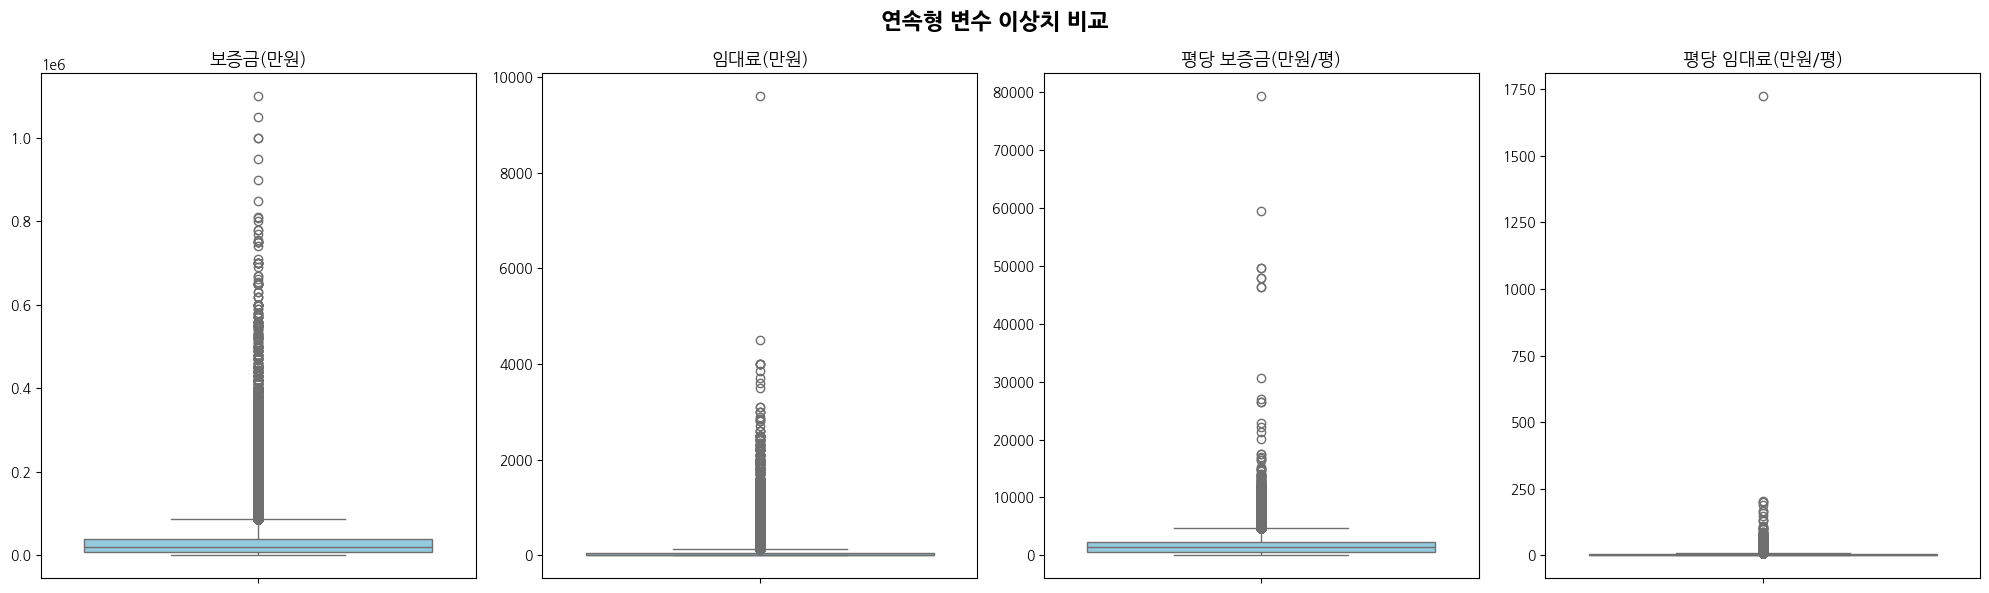

In [77]:
boxplot_cols = ["보증금(만원)", "임대료(만원)", "평당 보증금(만원/평)", "평당 임대료(만원/평)"]

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
for ax, col in zip(axes, boxplot_cols):
    sns.boxplot(y=df_base[col], ax=ax, color="skyblue")
    ax.set_title(col, fontsize=13)
    ax.set_ylabel("")

plt.suptitle("연속형 변수 이상치 비교", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

In [78]:
# 건축년도 / 임대면적 이상값 확인
CURRENT_YEAR = pd.Timestamp.now().year

invalid_year = df_base[(df_base["건축년도"] < 1900) | (df_base["건축년도"] > CURRENT_YEAR)]
invalid_area = df_base[(df_base["임대면적"] <= 0) | (df_base["임대면적"].isna())]

print(f"비정상 건축년도: {len(invalid_year):,}건")
print(f"임대면적 0 이하/결측: {len(invalid_area):,}건")

비정상 건축년도: 0건
임대면적 0 이하/결측: 9건


In [79]:
# 평당 임대료 기준 이상치 확인 및 `df_clean` 생성
q1 = df_base["평당 임대료(만원/평)"].quantile(0.25)
q3 = df_base["평당 임대료(만원/평)"].quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

pyeong_outlier_mask = (df_base["평당 임대료(만원/평)"] < lower) | (df_base["평당 임대료(만원/평)"] > upper)

print(f"하한: {lower:.2f} / 상한: {upper:.2f}")
print(f"이상치 건수: {pyeong_outlier_mask.sum():,}건 ({pyeong_outlier_mask.mean() * 100:.2f}%)")

df_clean = df_base[~pyeong_outlier_mask].copy()

print(f"\n제거 전: {len(df_base):,}건 → 제거 후: {len(df_clean):,}건")

하한: -5.97 / 상한: 9.94
이상치 건수: 244,563건 (6.87%)

제거 전: 3,560,050건 → 제거 후: 3,315,487건


In [95]:
# 계약일 기준 유효 기간 필터링(2016-01 ~ 2025-12)
DATE_COL = "계약일"

df_clean[DATE_COL] = pd.to_datetime(df_clean[DATE_COL].astype(str), format="mixed", errors="coerce")

before = len(df_clean)

df_clean = df_clean[
    (df_clean[DATE_COL] >= "2016-01-01") &
    (df_clean[DATE_COL] <= "2025-12-31")
].copy()

after = len(df_clean)

print(f"제거 전: {before:,}건")
print(f"범위 밖(2016년 이전 / 2026년 이후) 제거: {before - after:,}건")
print(f"제거 후: {after:,}건")

제거 전: 3,315,487건
범위 밖(2016년 이전 / 2026년 이후) 제거: 33,090건
제거 후: 3,282,397건


In [96]:
output_path = "/content/df_cleaned.csv"
df.to_csv(output_path,index=False,encoding="utf-8-sig")

## 2-5. 지하철 데이터 합치기

In [45]:
LINE_1_8 = "/content/subway_line1to8.csv"
LINE_9 = "/content/subway_line9.csv"

OUTPUT_FILE = "/content/subway_geocode.csv"

# 1. 파일 불러오기
df_1_8 = pd.read_csv(
    LINE_1_8,
    encoding="cp949"
)

df_9 = pd.read_csv(
    LINE_9,
    encoding="cp949"
)

# 2. 컬럼명 앞뒤 공백 및 쉼표 제거
for data in [df_1_8, df_9]:
    data.columns = (
        data.columns
        .str.strip()
        .str.strip(",")
    )

# 3. 9호선 컬럼명을 1~8호선 구조에 맞게 변경
df_9 = df_9.rename(
    columns={
        "역번호": "고유역번호(외부역코드)",
        "데이터기준일자": "작성일자"
    }
)

# 4. 필요한 컬럼 구조로 통일
common_columns = [
    "연번",
    "호선",
    "고유역번호(외부역코드)",
    "역명",
    "위도",
    "경도",
    "작성일자"
]


df_1_8 = df_1_8[common_columns]

df_9 = df_9[common_columns]


# 5. 1~8호선 + 9호선 통합
df_subway = pd.concat(
    [df_1_8, df_9],
    ignore_index=True
)

# 6. 연번 재부여
df_subway["연번"] = range(
    1,
    len(df_subway) + 1
)

# 7. 결과 확인
print("=" * 60)
print("서울 지하철 1~9호선 통합 완료")
print("=" * 60)

print(f"1~8호선: {len(df_1_8):,}건")
print(f"9호선:   {len(df_9):,}건")
print(f"전체:    {len(df_subway):,}건")

print("\n최종 컬럼:")
print(df_subway.columns.tolist())

print("\n호선별 역 개수:")
print(df_subway["호선"].value_counts().sort_index())

display(df_subway.head())


# 8. CSV 저장
df_subway.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)

print(f"\n저장 완료: {OUTPUT_FILE}")

서울 지하철 1~9호선 통합 완료
1~8호선: 276건
9호선:   13건
전체:    289건

최종 컬럼:
['연번', '호선', '고유역번호(외부역코드)', '역명', '위도', '경도', '작성일자']

호선별 역 개수:
호선
1    10
2    51
3    34
4    26
5    56
6    39
7    42
8    18
9    13
Name: count, dtype: int64


,연번,호선,고유역번호(외부역코드),역명,위도,경도,작성일자
0,1,1,150,서울,37.553150,126.972533,1974-02-28
1,2,1,151,시청,37.563590,126.975407,1974-08-15
2,3,1,152,종각,37.570203,126.983116,1974-08-15
3,4,1,153,종로3가,37.570429,126.992095,1974-08-15
4,5,1,154,종로5가,37.570971,127.001900,1974-03-31



저장 완료: /content/subway_geocode.csv


##2-6. 금리 데이터 조인

In [80]:
!pip install scikit-learn -q

In [97]:
from sklearn.neighbors import BallTree

# 지구 반지름 (미터)
EARTH_RADIUS_M = 6_371_000

In [98]:
# 분석에 필요한 컬럼만 선택
KEEP_COLS = [
    # 위치 정보
    "자치구명", "법정동명", "address", "위도", "경도",
    # 계약 정보
    "계약일", "전월세구분", "건물용도", "계약기간",
    # 면적/가격
    "임대면적", "보증금(만원)", "임대료(만원)",
    "면적당 보증금(만원/㎡)", "면적당 임대료(만원/㎡)",
    "평당 보증금(만원/평)", "평당 임대료(만원/평)",
]

df_selected = df_clean[KEEP_COLS].copy()
df_selected.head()

,자치구명,법정동명,address,위도,경도,계약일,전월세구분,건물용도,계약기간,임대면적,보증금(만원),임대료(만원),면적당 보증금(만원/㎡),면적당 임대료(만원/㎡),평당 보증금(만원/평),평당 임대료(만원/평)
0,용산구,원효로2가,서울특별시 용산구 원효로2가 1,37.537757,126.965287,2016-03-10,월세,오피스텔,NaN,22.03,1000,50,45.392646,2.269632,150.058330,7.502916
2,마포구,노고산동,서울특별시 마포구 노고산동 1-1,37.556248,126.942759,2016-01-04,월세,오피스텔,NaN,31.12,6000,50,192.802057,1.606684,637.362147,5.311351
3,마포구,노고산동,서울특별시 마포구 노고산동 1-1,37.556248,126.942759,2016-03-31,월세,오피스텔,NaN,31.12,6000,50,192.802057,1.606684,637.362147,5.311351
4,마포구,노고산동,서울특별시 마포구 노고산동 1-1,37.556248,126.942759,2016-07-05,월세,오피스텔,NaN,31.12,6000,50,192.802057,1.606684,637.362147,5.311351
5,마포구,노고산동,서울특별시 마포구 노고산동 1-1,37.556248,126.942759,2016-07-12,월세,오피스텔,NaN,31.12,6000,50,192.802057,1.606684,637.362147,5.311351


In [99]:
# 계약연월 파생
DATE_COL = "계약일"

df_selected[DATE_COL] = pd.to_datetime(df_selected[DATE_COL].astype(str), format="mixed", errors="coerce")

print(f"날짜 파싱 실패(결측): {df_selected[DATE_COL].isna().sum():,}건")

df_selected["계약연월"] = df_selected[DATE_COL].dt.to_period("M").astype(str)  # 'YYYY-MM'

df_selected[[DATE_COL, "계약연월"]].head()

날짜 파싱 실패(결측): 0건


,계약일,계약연월
0,2016-03-10,2016-03
2,2016-01-04,2016-01
3,2016-03-31,2016-03
4,2016-07-05,2016-07
5,2016-07-12,2016-07


In [100]:
# 금리 데이터 로드 및 월 단위로 정리
RATE_FILE = "/content/interest_rate.CSV" # 세 지표가 합쳐진 파일명으로 수정

rate_df = pd.read_csv(RATE_FILE, encoding="cp949")
rate_df.head()

,연월,한국은행 기준금리,정부대출금금리,국고채(10년)
0,Jan-16,1.5,1.664,2.025
1,Feb-16,1.5,1.664,1.826
2,Mar-16,1.5,1.664,1.854
3,Apr-16,1.5,1.602,1.810
4,May-16,1.5,1.602,1.787


In [101]:
# 날짜 컬럼: 'Jan-16' 형태 (%b-%y) → 연월(YYYY-MM)으로 변환
RATE_DATE_COL = "연월"
rate_df[RATE_DATE_COL] = pd.to_datetime(rate_df[RATE_DATE_COL], format="%b-%y", errors="coerce")
rate_df["계약연월"] = rate_df[RATE_DATE_COL].dt.to_period("M").astype(str)

# 세 금리 컬럼명을 분석용으로 통일
RATE_COLS_MAP = {
    "한국은행 기준금리": "기준금리",
    "정부대출금금리": "정부대출금리",
    "국고채(10년)": "국고채10년",
}
rate_df = rate_df.rename(columns=RATE_COLS_MAP)
rate_df = rate_df[["계약연월", *RATE_COLS_MAP.values()]].drop_duplicates(subset="계약연월")

print(f"금리 데이터: {len(rate_df):,}개월")
rate_df.head(10)

금리 데이터: 120개월


,계약연월,기준금리,정부대출금리,국고채10년
0,2016-01,1.50,1.664,2.025
1,2016-02,1.50,1.664,1.826
2,2016-03,1.50,1.664,1.854
3,2016-04,1.50,1.602,1.810
4,2016-05,1.50,1.602,1.787
5,2016-06,1.25,1.602,1.617
6,2016-07,1.25,1.453,1.401
7,2016-08,1.25,1.453,1.417
8,2016-09,1.25,1.453,1.512
9,2016-10,1.25,1.402,1.596


In [102]:
# 계약연월 기준으로 금리 데이터 조인
df_selected = df_selected.merge(rate_df, on="계약연월", how="left")

missing_rate = df_selected["기준금리"].isna().sum()
print(f"금리 매핑 실패(결측): {missing_rate:,}건")

if missing_rate > 0:
    # 거래 데이터의 계약연월 범위가 금리 데이터 수집 기간을 벗어나는지 확인
    missing_months = sorted(df_selected.loc[df_selected["기준금리"].isna(), "계약연월"].unique())
    print(f"금리 매핑 실패 계약연월: {missing_months}")

df_selected.head()

금리 매핑 실패(결측): 0건


,자치구명,법정동명,address,위도,경도,계약일,전월세구분,건물용도,계약기간,임대면적,보증금(만원),임대료(만원),면적당 보증금(만원/㎡),면적당 임대료(만원/㎡),평당 보증금(만원/평),평당 임대료(만원/평),계약연월,기준금리,정부대출금리,국고채10년
0,용산구,원효로2가,서울특별시 용산구 원효로2가 1,37.537757,126.965287,2016-03-10,월세,오피스텔,NaN,22.03,1000,50,45.392646,2.269632,150.058330,7.502916,2016-03,1.50,1.664,1.854
1,마포구,노고산동,서울특별시 마포구 노고산동 1-1,37.556248,126.942759,2016-01-04,월세,오피스텔,NaN,31.12,6000,50,192.802057,1.606684,637.362147,5.311351,2016-01,1.50,1.664,2.025
2,마포구,노고산동,서울특별시 마포구 노고산동 1-1,37.556248,126.942759,2016-03-31,월세,오피스텔,NaN,31.12,6000,50,192.802057,1.606684,637.362147,5.311351,2016-03,1.50,1.664,1.854
3,마포구,노고산동,서울특별시 마포구 노고산동 1-1,37.556248,126.942759,2016-07-05,월세,오피스텔,NaN,31.12,6000,50,192.802057,1.606684,637.362147,5.311351,2016-07,1.25,1.453,1.401
4,마포구,노고산동,서울특별시 마포구 노고산동 1-1,37.556248,126.942759,2016-07-12,월세,오피스텔,NaN,31.12,6000,50,192.802057,1.606684,637.362147,5.311351,2016-07,1.25,1.453,1.401


In [103]:
# 지하철역 데이터 확인
SUBWAY_NAME_COL = "역명"
SUBWAY_LINE_COL = "호선"
SUBWAY_LAT_COL = "위도"
SUBWAY_LON_COL = "경도"

subway_df = df_subway[[SUBWAY_NAME_COL, SUBWAY_LINE_COL, SUBWAY_LAT_COL, SUBWAY_LON_COL]].dropna().copy()

print(f"지하철역 수: {len(subway_df):,}개")
subway_df.head()

지하철역 수: 289개


,역명,호선,위도,경도
0,서울,1,37.553150,126.972533
1,시청,1,37.563590,126.975407
2,종각,1,37.570203,126.983116
3,종로3가,1,37.570429,126.992095
4,종로5가,1,37.570971,127.001900


In [104]:
# 최근접 지하철역 계산 (BallTree, haversine)
# 위경도 결측 행은 최근접역 계산에서 제외
geo_valid = df_selected["위도"].notna() & df_selected["경도"].notna()
print(f"위경도 있는 행: {geo_valid.sum():,}건 / 없는 행: {(~geo_valid).sum():,}건")

# 역 좌표 (라디안)
subway_coords_rad = np.radians(subway_df[[SUBWAY_LAT_COL, SUBWAY_LON_COL]].values)
tree = BallTree(subway_coords_rad, metric="haversine")

# 매물 좌표 (라디안)
target_coords_rad = np.radians(df_selected.loc[geo_valid, ["위도", "경도"]].values)

distances_rad, indices = tree.query(target_coords_rad, k=1)

distances_m = distances_rad.flatten() * EARTH_RADIUS_M
nearest_idx = indices.flatten()

위경도 있는 행: 3,282,397건 / 없는 행: 0건


In [105]:
# 최근접역 정보(역명, 호선, 거리)를 데이터에 결합
df_selected["최근접역"] = np.nan
df_selected["최근접역_호선"] = np.nan
df_selected["최근접역_거리(m)"] = np.nan

df_selected.loc[geo_valid, "최근접역"] = subway_df.iloc[nearest_idx][SUBWAY_NAME_COL].values
df_selected.loc[geo_valid, "최근접역_호선"] = subway_df.iloc[nearest_idx][SUBWAY_LINE_COL].values
df_selected.loc[geo_valid, "최근접역_거리(m)"] = distances_m

print(f"최근접역 거리 요약(m):")
display(df_selected["최근접역_거리(m)"].describe().round(1))

df_selected[["address", "최근접역", "최근접역_호선", "최근접역_거리(m)"]].head()

/tmp/ipykernel_1065/3282561445.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['효창공원앞' '이대' '이대' ... '온수' '온수' '삼전역']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_selected.loc[geo_valid, "최근접역"] = subway_df.iloc[nearest_idx][SUBWAY_NAME_COL].values


최근접역 거리 요약(m):


,최근접역_거리(m)
count,3282397.0
mean,705.7
std,904.9
min,27.7
25%,340.9
50%,517.0
75%,879.6
max,286137.7


,address,최근접역,최근접역_호선,최근접역_거리(m)
0,서울특별시 용산구 원효로2가 1,효창공원앞,6.0,386.317162
1,서울특별시 마포구 노고산동 1-1,이대,2.0,281.834875
2,서울특별시 마포구 노고산동 1-1,이대,2.0,281.834875
3,서울특별시 마포구 노고산동 1-1,이대,2.0,281.834875
4,서울특별시 마포구 노고산동 1-1,이대,2.0,281.834875


In [106]:
# 거리 구간 범주화
bins = [0, 250, 500, 1000, np.inf]
labels = ["0~250m", "250~500m", "500m~1km", "1km 이상"]

df_selected["거리구간"] = pd.cut(
    df_selected["최근접역_거리(m)"],
    bins=bins,
    labels=labels,
    right=False,
)

print("거리구간별 건수")
display(df_selected["거리구간"].value_counts().reindex(labels))

거리구간별 건수


,count
거리구간,
0~250m,447885
250~500m,1051503
500m~1km,1161009
1km 이상,622000


In [107]:
# 최종 결과 확인 및 저장

In [108]:
print(f"최종 데이터: {df_selected.shape}")
display(df_selected.isna().sum().sort_values(ascending=False).head(10))

OUTPUT_FILE = "Rental_Rate_Subway_Mapped.csv"
df_selected.to_csv(OUTPUT_FILE, index=False, encoding="utf-8-sig")
print(f"저장 완료: {OUTPUT_FILE}")

최종 데이터: (3282397, 24)


,0
계약기간,1789271
전월세구분,9
평당 보증금(만원/평),8
면적당 임대료(만원/㎡),8
면적당 보증금(만원/㎡),8
평당 임대료(만원/평),8
address,0
자치구명,0
건물용도,0
계약일,0


저장 완료: Rental_Rate_Subway_Mapped.csv


In [109]:
df_selected.columns

Index(['자치구명', '법정동명', 'address', '위도', '경도', '계약일', '전월세구분', '건물용도', '계약기간',
       '임대면적', '보증금(만원)', '임대료(만원)', '면적당 보증금(만원/㎡)', '면적당 임대료(만원/㎡)',
       '평당 보증금(만원/평)', '평당 임대료(만원/평)', '계약연월', '기준금리', '정부대출금리', '국고채10년',
       '최근접역', '최근접역_호선', '최근접역_거리(m)', '거리구간'],
      dtype='object')